In [1]:
import pygmo as pg
import numpy as np
import os
import sys
sys.path.append("/home/jlgpke/projects/UCL/research_project/topological_insulator/notebooks/project/")
from topological_insulator import Problem
from mean_field_problem import MeanFieldProblem

In [2]:
structure_path = "../../../../../topological_insulator/data/structures/"
structure_name = "kagome.json"

In [3]:
mean_field_problem = MeanFieldProblem(
    structure_path, structure_name, Delta_SOC=-5,
    t=-1, U=0, delta=0.83, occupations= np.zeros(24)
)

In [4]:
problem = Problem(
            structure_path=structure_path, structure_name=structure_name)
mean_field_problem._set_eigenvalues(problem, np.zeros(24))
problem.setup(
    N_r = 10,
    N_k = 400,
    location = "bulk",
    BZ = "reduced"
)
problem.run(
    H_type="reciprocal"
)
g = problem.geometry
tb_bulk = problem.hamiltonian["bulk"]["tight_binding"]
invariants = problem.hamiltonian["bulk"]["topological_invariants"]

Building Geometry...
Geometry - Done.
Building 'Bulk' Hamiltonian...
'Bulk' Hamiltonian - Done.
Calculating 'Bulk' Eigenvalues...
'Bulk' Eigenvalues - Done!


In [5]:
j_3_2 = [i for i in range(8, 25)]

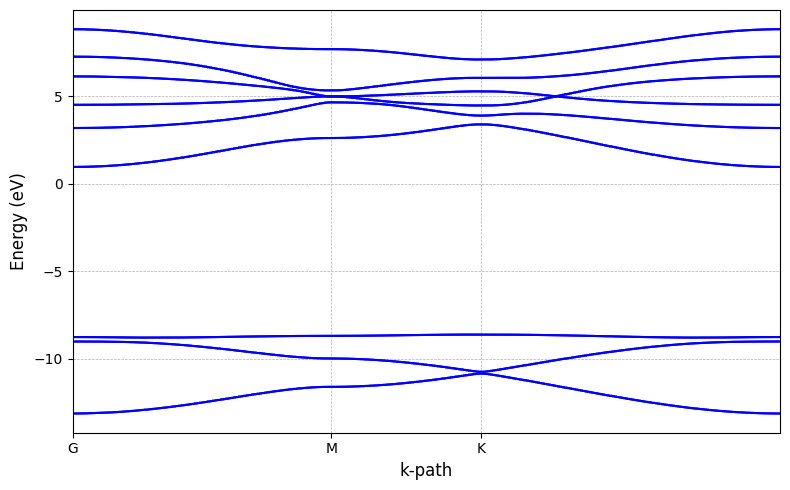

In [6]:
tb_bulk.plot_band_structure(g)

In [7]:
E, DOS = mean_field_problem.density_of_states(g, tb_bulk, invariants, E_max=10, E_min=1)

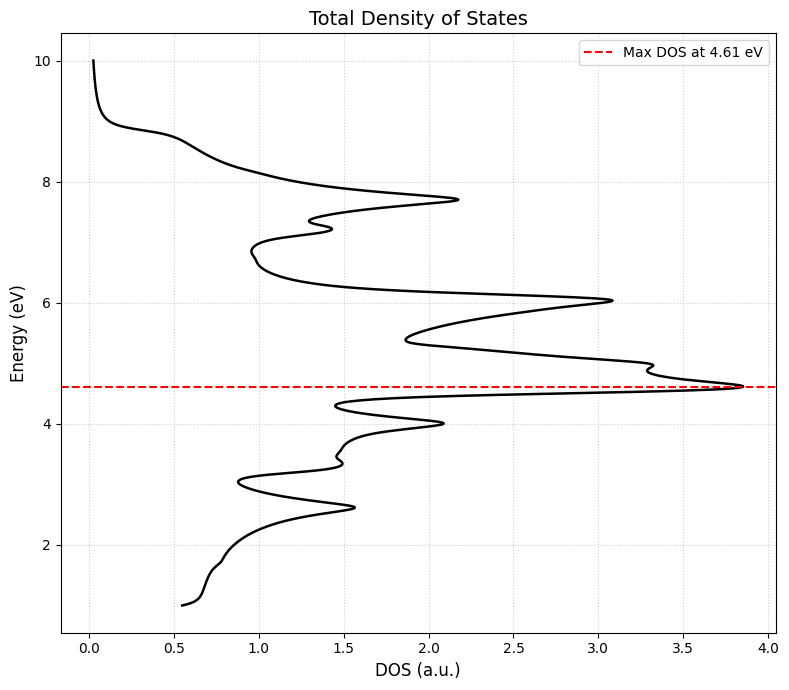

In [8]:
invariants.plot_density_of_states(E, DOS, xlabel="DOS")

In [9]:
E_h = E
mu_min = np.min(E_h)
mu_max = np.max(E_h)
mu = mean_field_problem.find_chemical_potential(E_h, DOS, 3, 300, mu_min=mu_min, mu_max=mu_max)
print(f"mu = {mu}")

mu = 6.277559730853039


In [10]:
occupations_new = mean_field_problem.get_occupations(g, tb_bulk, E, mu, T = 300)

In [11]:
occupations_new

array([0.00000000e+00, 0.00000000e+00, 4.12128863e-01, 4.12128863e-01,
       4.79446040e-01, 4.79446040e-01, 6.21098242e-01, 6.21098242e-01,
       4.92457789e-30, 1.12719673e-30, 4.12128863e-01, 4.12128863e-01,
       4.79446040e-01, 4.79446040e-01, 6.21098242e-01, 6.21098242e-01,
       1.21587886e-31, 1.43413206e-31, 5.13016822e-01, 5.13016822e-01,
       3.78850311e-01, 3.78850311e-01, 6.21103404e-01, 6.21103404e-01])

In [ ]:
N_e = np.sum(occupations_new)
N_e

np.float64(9.074996440133093)

In [12]:
import numpy as np
def get_occupations(self, g, tb_bulk, E, mu, T):
        E_max, E_min = max(E), min(E)
        M = tb_bulk.C @ tb_bulk.A
        M_sub = np.kron(np.eye(self.N_sites), M.conj().T)
        N_projections = len(tb_bulk.coupled_states)
        N_sites = len(tb_bulk.sublattice_idxs)
        N_bands = N_sites * N_projections
        kx = g.kx_bulk
        ky = g.ky_bulk
        occupations = np.zeros(N_bands)
        for ix, k_x in enumerate(kx):
            for iy, k_y in enumerate(ky):
                if not g.BZ_mask[ix, iy]:
                    continue
                key =  f"[{k_x}, {k_y}]"
                U_k = tb_bulk.U_k_dict[key]
                E_k = tb_bulk.E_k_dict[key]
                for band in range(N_bands):
                    E_k_m = E_k[band]
                    if E_k_m > E_max or E_k_m < E_min:
                        continue
                    c_k_m = M_sub @ U_k[:, band]
                    occupations += (
                        np.abs(c_k_m)**2 * (1-self._fermi_dirac_distribution(E_k_m, mu, T))
                    )
        occupations /= self.N_k_BZ
        return occupations
occupations_hole = get_occupations(mean_field_problem, g, tb_bulk, E, mu, 300)

In [13]:
occupations_hole

array([0.00000000e+00, 0.00000000e+00, 2.47407345e-01, 2.47407345e-01,
       1.85287972e-01, 1.85287972e-01, 5.09107550e-02, 5.09107550e-02,
       3.90148925e-31, 1.28629423e-31, 2.47407345e-01, 2.47407345e-01,
       1.85287972e-01, 1.85287972e-01, 5.09107550e-02, 5.09107550e-02,
       7.17417359e-33, 9.19004097e-33, 1.54308908e-01, 1.54308908e-01,
       2.78097113e-01, 2.78097113e-01, 5.09027054e-02, 5.09027054e-02])

In [14]:
sum(occupations_hole)

np.float64(2.9010417415403777)

In [14]:
N_h = 3
tol = 1e-5
occupations_old  = [
    0, 0, 0.333, 0, 0.333, 0., 0.333, 0,
    0, 0, 0, 0.333, 0, 0.333, 0., 0.333,
    0, 0, 0.333, 0, 0.333, 0., 0.333, 0,
] # antiferromagnet
converged = False
counter = 0
results = {}
while not converged:
    mean_field_problem = MeanFieldProblem(
    structure_path, structure_name, Delta_SOC=-5,
    t=-1, U=1, delta=0.832, occupations=occupations_old
    )
    occupations_new, mu = mean_field_problem._objective(
        occupations=occupations_old, 
        E_max=10, 
        E_min=1, 
        eta=0.08, 
        mu_max=10, 
        mu_min=5, 
        T=300, 
        N_e=N_h
    )
    results[counter] = occupations_new
    diff = np.abs(occupations_old - occupations_new)
    print(counter, diff)
    converged = np.all(diff < tol)
    occupations_old = occupations_new
    counter +=1


Building Geometry...
Geometry - Done.
Building 'Bulk' Hamiltonian...
'Bulk' Hamiltonian - Done.
Calculating 'Bulk' Eigenvalues...
'Bulk' Eigenvalues - Done!
0 [0.00000000e+00 0.00000000e+00 8.80753675e-02 4.05004512e-01
 1.50337541e-01 4.70572822e-01 2.79748507e-01 6.25980811e-01
 4.43746096e-30 1.36669705e-30 4.10720887e-01 7.76650367e-02
 4.86305176e-01 1.56068899e-01 6.20568772e-01 2.86116988e-01
 1.15323106e-31 1.36441956e-31 1.82449469e-01 5.10023838e-01
 3.53896400e-02 3.89293888e-01 2.90048204e-01 6.20416395e-01]

Building Geometry...
Geometry - Done.
Building 'Bulk' Hamiltonian...
'Bulk' Hamiltonian - Done.
Calculating 'Bulk' Eigenvalues...
'Bulk' Eigenvalues - Done!
1 [0.00000000e+00 0.00000000e+00 9.41168381e-02 7.89478299e-02
 8.46349115e-02 7.41931280e-02 6.17578377e-03 1.79433796e-02
 3.08827621e-30 1.06008311e-30 8.81456796e-02 8.82560077e-02
 8.14991939e-02 8.15029743e-02 3.13067083e-03 1.31557109e-02
 6.15086532e-32 7.24728548e-32 6.61496933e-02 7.36696834e-02
 8.37694

KeyboardInterrupt: 

In [15]:
occupations_new

array([0.00000000e+00, 0.00000000e+00, 3.47101420e-01, 3.45440697e-01,
       4.15410980e-01, 4.14023988e-01, 6.12272458e-01, 6.12909684e-01,
       1.71240787e-30, 3.62098699e-31, 3.40738783e-01, 3.43692217e-01,
       4.23108968e-01, 4.27190153e-01, 6.21559308e-01, 6.10092104e-01,
       6.01848547e-32, 7.02448156e-32, 4.67221720e-01, 4.49893044e-01,
       3.05932798e-01, 3.10482690e-01, 6.06547490e-01, 6.18817114e-01])

In [16]:
print(f"N_e = {sum(occupations_new)}, mu = {mu}")

N_e = 8.272435616042248, mu = 5.124662182158363
